# Rural Detention Centers (Early) Analysis

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import pytidycensus as tc
import os
from dotenv import load_dotenv
import glob
from concurrent.futures import ThreadPoolExecutor
from typing import Dict, Literal
from qbstyles import mpl_style

%config InlineBackend.figure_format = 'retina'

mpl_style(dark=True)


from pyresearch import collect_acs_data


/tmp/ipykernel_54308/3179942047.py:5: UserWarning: Mapping functions unavailable due to import error: NameError. To use mapping features, ensure all dependencies are properly installed: pip install pytidycensus[map]
  import pytidycensus as tc


In [2]:
load_dotenv()

API_KEY: str = os.getenv("CENSUS_KEY")
DATA: str = os.getenv("DATA")

pd.set_option("future.no_silent_downcasting", True)

tc.set_census_api_key(API_KEY)



Census API key has been set for this session.


## RUCC Codes

|Code|Description|Category|
|---|---|---|
|1|Counties in metro areas of 1 million population or more|Metropolitan|
|2|Counties in metro areas of 250,000 to 1 million population|Metropolitan|
|3|Counties in metro areas of fewer than 250,000 population|Metropolitan|
|4|Urban population of 20,000 or more, adjacent to a metro area|Nonmetropolitan|
|5|Urban population of 20,000 or more, not adjacent to a metro area|Nonmetropolitan|
|6|Urban population of 5,000 to 20,000, adjacent to a metro area|Nonmetropolitan|
|7|Urban population of 5,000 to 20,000, not adjacent to a metro area|Nonmetropolitan|
|8|Urban population of fewer than 5,000, adjacent to a metro area|Nonmetropolitan|
|9|Urban population of fewer than 5,000, not adjacent to a metro area|Nonmetropolitan|


In [3]:
rucc = pd.read_csv(f"{DATA}/RUCC.csv")
rucc.drop(columns=["Population_2020", "Description"], inplace=True)
rucc.rename(columns={"RUCC_2023": "RUCC"}, inplace=True)
rucc["County_Name"] = rucc["County_Name"].str.replace("County", "")
rucc["County_Name"] = rucc["County_Name"].str.replace("Parish", "")
rucc["County_Name"] = rucc["County_Name"].str.strip()
rucc.rename(columns={"State": "state", "County_Name": "county"}, inplace=True)

rucc.head()


,FIPS,state,county,RUCC
0,1001,AL,Autauga,2.0
1,1003,AL,Baldwin,3.0
2,1005,AL,Barbour,6.0
3,1007,AL,Bibb,1.0
4,1009,AL,Blount,1.0


In [4]:
# plt.figure(figsize=(8, 6))
# plt.hist(rucc["RUCC"], bins=9, edgecolor="black", alpha=0.7)
# plt.title("RUCC Code Distribution", fontsize=14)
# plt.xlabel("RUCC Code", fontsize=10)
# plt.ylabel("Frequency", fontsize=10)
# plt.grid(False, axis="x")
# plt.grid(True, axis="y", alpha=0.5)
# plt.show()


In [5]:
# # Dataframe of all variables
# acs_vars = tc.load_variables(2023, "acs", 'acs5', cache=True)
# print(acs_vars.head())


In [6]:
# Search for income-related variables
# var_search = tc.search_variables("earnings", 2023, "acs", "acs5"
# )

# var_search.drop(columns=['predicateType', 'limit', 'name', 'label'], inplace=True)
# var_search.dropna(inplace=True)
# var_search.drop_duplicates(subset=["concept"])


In [7]:
vars = {
    "pov_under_50": "C17002_002E",
    "pov_under_100": "C17002_003E",
    "white": "B01001A_001E",
    "black": "B01001B_001E",
    "total_pop": "B01003_001E",
    "am_in_ala_nat": "B01001C_001E",
    "asian": "B01001D_001E",
    "haw_pac": "B01001E_001E",
    "other": "B01001F_001E",
    "hisp_lat": "B01001I_001E",
    "male_no_hs": "C15002A_003E",
    "fem_no_hs": "C15002A_008E",
    "not_citizen": "B05001_006E",
    "median_earnings": "B08521_001E",
    "gini_index": "B19083_001E",
}

results = tc.get_table_variables(
    year="2023", dataset="acs", survey="acs5", table="B19083"
)
results.drop_duplicates(subset=["concept"])


Loaded cached variables for 2023 acs acs5


,name,label,concept,predicateType,group,limit,table
0,B19083_001E,Estimate!!Gini Index,Gini Index of Income Inequality,float,B19083,0,B19083


In [8]:
# Get census data for each state

# C17002_001E: count of ratio of income to poverty in the past 12 months (total)
# C17002_002E: count of ratio of income to poverty in the past 12 months (< 0.50)
# C17002_003E: count of ratio of income to poverty in the past 12 months (0.50 - 0.99)
# B01003_001E: total population
# Sources: https://api.census.gov/data/2019/acs/acs5/variables.html

states_to_remove = [
    "PR",
    "HI",
    "GU",
    "MP",
    "AS",
    "AK",
    "VI",
]  # Filter states to continental US + D.C.

states = [
    state
    for state in sorted(list(set(rucc["state"].values.tolist())))
    if state not in states_to_remove
]


census = collect_acs_data(
    geography='county',
    states=states,
    
    vars=vars,
    max_workers=10
    )
census["poverty"] = census["pov_under_50"] + census["pov_under_100"]
census["no_hs"] = census["male_no_hs"] + census["fem_no_hs"]

scale_to_pop = [
    "poverty",
    "no_hs",
    "white",
    "black",
    "am_in_ala_nat",
    "asian",
    "haw_pac",
    "other",
    "hisp_lat",
    "not_citizen",
]

for var in scale_to_pop:
    census[var] = census[var] / census["total_pop"]

census.drop(columns=["pov_under_50", "pov_under_100", "male_no_hs", "fem_no_hs", 'county', 'state'], inplace=True)
print(census.info())
census.head()


TypeError: collect_acs_data() missing 2 required positional arguments: 'API_KEY' and 'year'

## Detention Data

### Overview

From [dataset Github](https://github.com/vera-institute/ice-detention-trends/tree/main#about-the-data)

> Vera’s ICE Detention Trends dashboard reveals an unprecedented level of detail about ICE detention populations—nationally and across the 1,464 facilities in which ICE detained people—on each day of the 16-year period from fiscal year 2009 through the beginning of fiscal year 2026 (October 1, 2008, through October 15, 2025). This repository includes the aggregated data visualized in the dashboard, including information on:
>
> - Midnight population: the daily number of people detained at midnight (nationally and by facility).
> - 24-hour population: the number of people detained for any part of a given day, including those whom ICE transferred or booked-out of custody before midnight (nationally and by facility). While ICE relies solely on midnight populations in its reporting, Vera includes both types of daily populations—midnight and 24-hour—as the two can differ drastically.
> - Book-ins: the daily number of people ICE booked into custody (nationally).
> - Book-outs: the daily number of people ICE booked out of custody (nationally).
> - Facility names, locations, and types (as coded by ICE in other datasets, where available).
> 
> The original datasets included facility names and codes, but no information on location or facility type. Vera drew from additional datasets and public sources to geocode facility > locations and assign facility types. Given the lack of a comprehensive, up-to-date ICE source to assign facility types to all 1,464 facility codes in the dataset, Vera’s categorizations should be interpreted as best-known facility type. To simplify map filtering options, Vera grouped facility types assigned by ICE, as well as ones manually entered by Vera, into the following categories:
>
> - Non-Dedicated: IGSA (Inter-governmental Service Agreement).
> - Dedicated: DIGSA (Dedicated IGSA), SPC (Service Processing Center), CDF (Contract Detention Facility).
> - Federal: USMS IGA (U.S. Marshals Service Inter-governmental Agreement), BOP (Bureau of Prisons), USMS CDF (U.S. Marshals Service Contract Detention Facility), DOD (Department of Defense), MOC (Migrant Operations Center). Because ICE can be added to other federal agencies’ facility contracts or agreements through a “rider,” Vera reports federal facilities as a separate category, rather than grouped with other categories such as non-dedicated facilities.
> - Hold/Staging.
> - Family/Youth: Family, Family Staging, Juvenile. ICE’s use of the “Juvenile” facility type reflects ICE detention and does not refer to facilities used to detain unaccompanied children in the custody of the Office of Refugee Resettlement (ORR).
> - Medical: Facilities coded by ICE as “Hospital” and medical or mental health facilities manually coded by Vera.
> - Hotel: Facilities coded by ICE as “Hotel” and facilities manually coded by Vera.
> - Other/Unknown: Facilities coded by ICE as “Other” or ones for which Vera was unable to assign facility type.


### Facilities

#### Variables

> The ICE detention datasets include facility names and codes, but no information on location or facility type. Vera drew from additional datasets and public sources to geocode facility locations and assign facility types. Given the lack of a comprehensive, up-to-date ICE source to assign facility types to all facility codes in the dataset, Vera’s categorizations should be interpreted as best-known facility type.


|Variable|Type|Description|
|---|---|---|
|detention_facility_code|`string`|The unique identifier used in the ICE detention data for each facility|
|detention_facility_name|`string`|The facility name associated with the detention_facility_code in the ICE detention data|
|latitude|`numeric`|The latitude coordinate of the facility location|
|longitude|`numeric`|The longitude coordinate of the facility location|
|address|`string`|The best known facility address|
|city|`string`|The city in which the facility is located|
|county|`string`|The county in which the facility is located|
|state|`string`|The state abbreviation code. This also includes codes for U.S. territories (e.g. "PR" for "Puerto Rico") and Cuba ("CU") for facilities at Naval Station Guantanamo Bay.|
|aor|`aor`|The ICE Area of Responsibility (AOR), originally mapped by Will Craft of the Guardian US. This reflects county boundaries extracted from ICE's [field office map](https://www.ice.gov/doclib/about/offices/ero/pdf/eroFieldOffices.pdf), last updated by ICE in February 2024.|


In [ ]:
if "facilities" not in locals():
    print("Processing facilities data")
    facilities = pd.read_csv(f"{DATA}/ice-detention-trends/metadata/facilities.csv")
    facilities.drop(columns=["address", "1
                             city", "zip"], inplace=True)

    facilities.rename(columns={"FIPS": "GEOID"}, inplace=True)
    facilities.drop(columns=["detention_facility_name", "state"], inplace=True)
    facilities.sort_values("county", inplace=True)
else:
    print("facilities data already processed")
facilities.head()


Processing facilities data


,detention_facility_code,county,aor,latitude,longitude,type_detailed,type_grouped
126,BOIHOLD,Ada,Salt Lake City,43.592766,-116.286069,Hold,Hold/Staging
6,ADACOID,Ada,Salt Lake City,43.606755,-116.269811,IGSA,Non-Dedicated
7,ADAIRKY,Adair,Chicago,37.103848,-85.306634,Other,Other/Unknown
114,BIINCCO,Adams,Denver,39.760890,-104.849106,Unknown,Other/Unknown
395,DENICDF,Adams,Denver,39.766325,-104.864502,CDF,Dedicated


### State Data

Facility-level population statistics for each day between October 1, 2008, and October 15, 2025, including midnight population and 24-hour population. 


|Variable|Type|Description|
|---|---|---|
|detention_facility_code|`string`|The unique identifier used in the ICE detention data for each facility|
|detention_facility_name|`string`|The facility name associated with the detention_facility_code in the ICE detention data|
|state|`string`|The state abbreviation code. This also includes codes for U.S. territories (e.g. "PR" for "Puerto Rico") and Cuba ("CU") for facilities at Naval Station Guantanamo Bay.|
|date|`date`|The day each count is reported for (`yyyy-mm-dd` format)|
|daily_pop|`numeric`|24-hour population: the number of people detained for any part of a given day, including those whom ICE transferred or booked-out of custody before midnight|
|midnight_pop|`numeric`|Midnight population: the daily number of people detained at midnight|


In [ ]:
if "state_data" not in locals():
    print("Processing state detention data")
    state_dir = f"{DATA}/ice-detention-trends/facilities/by_state"
    file_pattern = os.path.join(state_dir, "*.csv")
    csvs = glob.glob(file_pattern)
    state_data = pd.concat(
        [pd.read_csv(csv) for csv in csvs], ignore_index=True, sort=False
    )
    state_data["date"] = pd.to_datetime(state_data["date"])

else:
    print("state detention data already processed")


Processing state detention data


## Data Processing

This first table shows the structure of the data once the facilities data is merged with the daily data.



In [ ]:
if "df" not in locals():
    df = pd.merge(
        state_data,
        facilities,
        on="detention_facility_code",
        how="left",
        # validate="many_to_one",
    )
    df["year"] = df["date"].dt.year

    df["daily_change"] = df["daily_pop"] - df["midnight_pop"]

    df = pd.merge(
        df,
        rucc,
        on=["state", "county"],
        how="left",
        # validate="many_to_one",
    )

    df.rename(columns={"FIPS": "GEOID"}, inplace=True)

missing_rucc = df["RUCC"].isna().sum()
missing_counties = df["county"].isna().sum()
missing_states = df["state"].isna().sum()

print(
    f"Total Observations: {len(df)},\n Missing states: {missing_states},\n Missing counties: {missing_counties},\n Missing RUCC codes: {missing_rucc}"
)

print(
    f"----------------------\nColumns: {', '.join([col for col in list(df.columns)])}"
)
df.head()


Total Observations: 8875424,
 Missing states: 0,
 Missing counties: 24896,
 Missing RUCC codes: 634848
----------------------
Columns: detention_facility_code, detention_facility_name, state, date, daily_pop, midnight_pop, county, aor, latitude, longitude, type_detailed, type_grouped, year, daily_change, GEOID, RUCC, white, black, total_pop, am_in_ala_nat, asian, haw_pac, other, hisp_lat, not_citizen, median_earnings, gini_index, NAME, poverty, no_hs


,detention_facility_code,detention_facility_name,state,date,daily_pop,midnight_pop,county,aor,latitude,longitude,...,asian,haw_pac,other,hisp_lat,not_citizen,median_earnings,gini_index,NAME,poverty,no_hs
0,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-01,0.0,0.0,Nye,Salt Lake City,36.219543,-115.982801,...,0.019621,0.005206,0.072829,0.164095,0.032421,45790.0,0.4427,"Nye County, Nevada",0.151879,0.065217
1,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-02,0.0,0.0,Nye,Salt Lake City,36.219543,-115.982801,...,0.019621,0.005206,0.072829,0.164095,0.032421,45790.0,0.4427,"Nye County, Nevada",0.151879,0.065217
2,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-03,0.0,0.0,Nye,Salt Lake City,36.219543,-115.982801,...,0.019621,0.005206,0.072829,0.164095,0.032421,45790.0,0.4427,"Nye County, Nevada",0.151879,0.065217
3,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-04,0.0,0.0,Nye,Salt Lake City,36.219543,-115.982801,...,0.019621,0.005206,0.072829,0.164095,0.032421,45790.0,0.4427,"Nye County, Nevada",0.151879,0.065217
4,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-05,0.0,0.0,Nye,Salt Lake City,36.219543,-115.982801,...,0.019621,0.005206,0.072829,0.164095,0.032421,45790.0,0.4427,"Nye County, Nevada",0.151879,0.065217


I'm not totally sure why there's 630,000 observations with missing RUCC codes. I played around with it for a long time and couldn't get the number to go down. Definitely a question for Matt because he knows a lot about set theory. The only thing that effects is the RUCC averages at the very bottom.

---

### Cumulative Change Over Time



In [ ]:
daily_ts = (
    df[["date", "daily_pop", "midnight_pop", "daily_change"]]
    .groupby("date")
    .sum()
    .reset_index()
)
daily_ts["year"] = daily_ts["date"].dt.year
daily_ts["month"] = daily_ts["date"].dt.month

daily_stats = round(daily_ts.drop(["year", "month", "date"], axis=1).describe(), 2)


# Add cumulative sums
daily_ts["daily_cumulative"] = daily_ts["daily_pop"].cumsum()
daily_ts["midnight_cumulative"] = daily_ts["midnight_pop"].cumsum()
daily_ts["change_cumulative"] = daily_ts["daily_change"].cumsum()

monthly_ts = (
    daily_ts.groupby(["year", "month"])
    .agg(
        {
            "daily_pop": "mean",
            "midnight_pop": "mean",
            "daily_change": "mean",
        }
    )
    .reset_index()
)

monthly_ts.rename(
    columns={
        "daily_pop": "avg_daily_pop",
        "midnight_pop": "avg_midnight_pop",
        "daily_change": "avg_daily_change",
    },
    inplace=True,
)


daily_ts = pd.merge(
    daily_ts,
    monthly_ts,
    on=["year", "month"],
    how="left",
    # validate="many_to_one",
)

print(
    "Descriptive Stats: Daily\n",
)

mean = daily_ts["daily_pop"].mean()
std = daily_ts["daily_pop"].std()

print(f"68% of data between: {mean - std:.1f} and {mean + std:.1f}")
print(f"95% of data between: {mean - 2*std:.1f} and {mean + 2*std:.1f}")
print(f"99.7% of data between: {mean - 3*std:.1f} and {mean + 3*std:.1f}")

daily_stats


Descriptive Stats: Daily

68% of data between: 26500.9 and 44316.5
95% of data between: 17593.1 and 53224.3
99.7% of data between: 8685.3 and 62132.1


,daily_pop,midnight_pop,daily_change
count,6224.00,6224.00,6224.00
mean,35408.69,33429.30,1979.39
std,8907.79,8423.86,1187.01
min,13353.00,12969.00,47.00
25%,30896.00,29411.00,782.00
50%,35212.00,32824.00,2111.00
75%,39736.75,37581.50,3007.00
max,65533.00,61274.00,5001.00


Initial Observations on the descriptive statistics:
- The narrow distance between the average daily population and the average midnight population as well as the moderate standard deviation indicates that there is high turnover with consistent occupancy levels over the whole period of the dataset
    - The limitation to this observation is, as the time series plots below show, there are a lot of peaks and valleys to the data. The size of the sample size (6224 records/days)
- The absolute minimum (12,969) for the daily population is within the range of the absolute highest days, the 0.3 percent of days (~19 days) with the highest levels.
    - This indicates that despite the peaks and valleys, the system rarely operates at what could be considered "low" occupancy rates.
    - The plots below show a huge decline starting in late 2019 and hitting the overall low in mid-late 2021.
        - Presumably this is due to various measures put in place because of COVID-19, assuming measures were taken regarding immigrant detention as with like traditional state prisons.
- Every 2/3 days there were between 26,501 and 44,317 people incarcerated in the system.

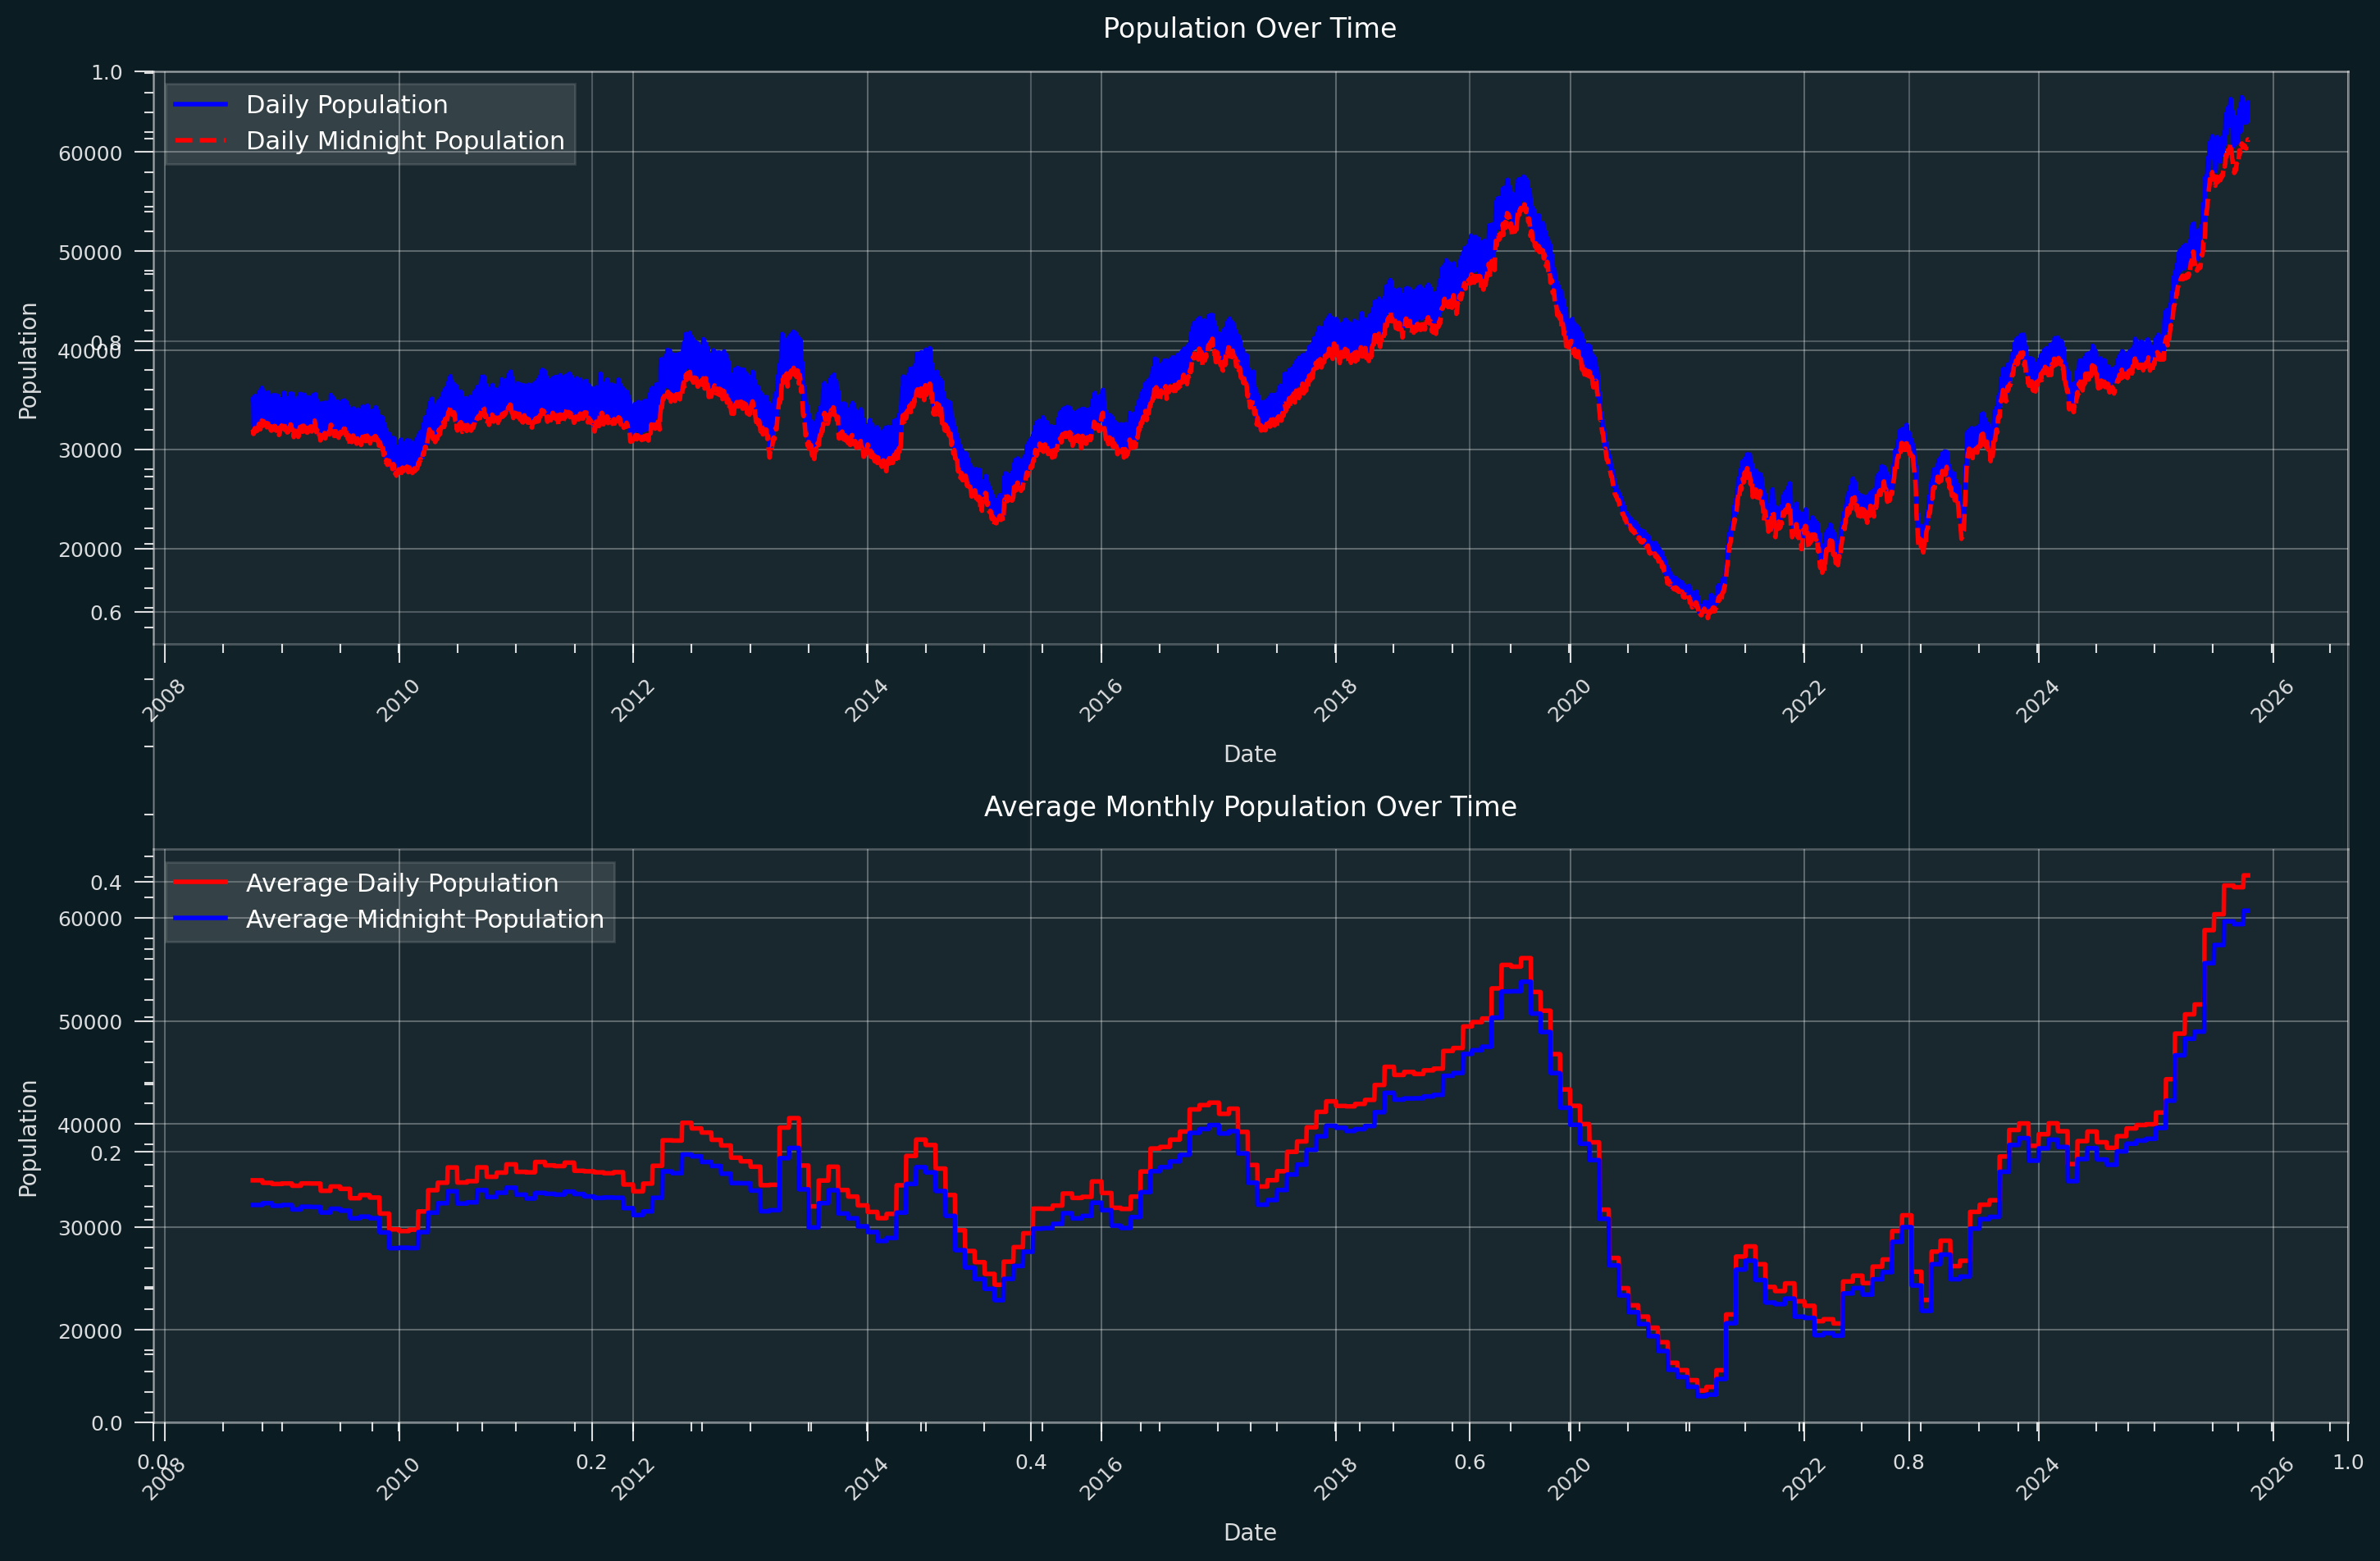

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))  # 2 rows, 1 column

# First plot: Population Over Time (top)
axes[0].plot(
    daily_ts["date"],
    daily_ts["daily_pop"],
    label="Daily Population",
    linewidth=2,
    color="blue",
)
axes[0].plot(
    daily_ts["date"],
    daily_ts["midnight_pop"],
    label="Daily Midnight Population",
    linewidth=2,
    color="red",
    linestyle="--",
)

axes[0].set_title("Population Over Time", fontsize=12)
axes[0].set_xlabel("Date", fontsize=10)
axes[0].set_ylabel("Population", fontsize=10)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

# Second plot: Average Monthly Population Over Time (bottom)
axes[1].plot(
    daily_ts["date"],
    daily_ts["avg_daily_pop"],
    label="Average Daily Population",
    linewidth=2,
    color="red",
)

axes[1].plot(
    daily_ts["date"],
    daily_ts["avg_midnight_pop"],
    label="Average Midnight Population",
    linewidth=2,
    color="blue",
)

axes[1].set_title("Average Monthly Population Over Time", fontsize=12)
axes[1].set_xlabel("Date", fontsize=10)
axes[1].set_ylabel("Population", fontsize=10)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


I don't remember how to do it but I'll try to find how the correct way to overlay the average daily population line over the daily population line, but I think these visualizations do a good job at reflecting the high level of variation day-to-day compared to the overall long-term increases.

---

### Detention Levels On the Rural-Urban Continuum

In [ ]:
rucc_group = (
    df[["RUCC", "daily_pop", "midnight_pop", "daily_change"]]
    .groupby("RUCC")
    .sum()
    .reset_index()
)

rucc_group["daily_pop"] = rucc_group["daily_pop"] / rucc_group["daily_pop"].sum()
rucc_group["midnight_pop"] = (
    rucc_group["midnight_pop"] / rucc_group["midnight_pop"].sum()
)

rucc_group["daily_change"] = (
    rucc_group["daily_change"] / rucc_group["daily_change"].sum()
)


rucc_group = round(rucc_group, 2)
print("Averages per RUCC code")
rucc_group


Averages per RUCC code


,RUCC,daily_pop,midnight_pop,daily_change
0,1.0,0.43,0.42,0.50
1,2.0,0.18,0.18,0.22
2,3.0,0.07,0.07,0.08
3,4.0,0.06,0.06,0.04
4,5.0,0.00,0.00,0.01
5,6.0,0.16,0.17,0.09
6,7.0,0.02,0.02,0.01
7,8.0,0.07,0.07,0.04
8,9.0,0.02,0.02,0.01


- I'm not particularly surprised by this, I definitely need to do a time-series analysis on how the RUCC averages change over time.

- I do find the differences in the daily change to be quite interesting. Based on the RUCC distribution from earlier there's definitely a disproportionate amount of activity in RUCC 1 and 2. I wonder if this is similar to like electoral maps in presidential elections where at the county level the map looks incredibly red but if you account for population it highlights the differences in the number of people between red and blue areas.  

- An observation that I do think is quite interesting is the difference in the turnover rate, on average it looks like people are much likely to stay for a shorter period of time in RUCC 1/2 but the length of stay, using the turnover rate as a proxy since right now we don't have data on length of stay, appears to be much longer the more rural the county someone is detained in. 

- I would have to dig more into the county level groupings but it is interesting that the middle of the road RUCC code appears to have very low variation, not quite sure what to make of it at the moment.

|Code|Description|Category|
|---|---|---|
|1|Counties in metro areas of 1 million population or more|Metropolitan|
|2|Counties in metro areas of 250,000 to 1 million population|Metropolitan|
|3|Counties in metro areas of fewer than 250,000 population|Metropolitan|
|4|Urban population of 20,000 or more, adjacent to a metro area|Nonmetropolitan|
|5|Urban population of 20,000 or more, not adjacent to a metro area|Nonmetropolitan|
|6|Urban population of 5,000 to 20,000, adjacent to a metro area|Nonmetropolitan|
|7|Urban population of 5,000 to 20,000, not adjacent to a metro area|Nonmetropolitan|
|8|Urban population of fewer than 5,000, adjacent to a metro area|Nonmetropolitan|
|9|Urban population of fewer than 5,000, not adjacent to a metro area|Nonmetropolitan|


/tmp/ipykernel_1408166/3177892684.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


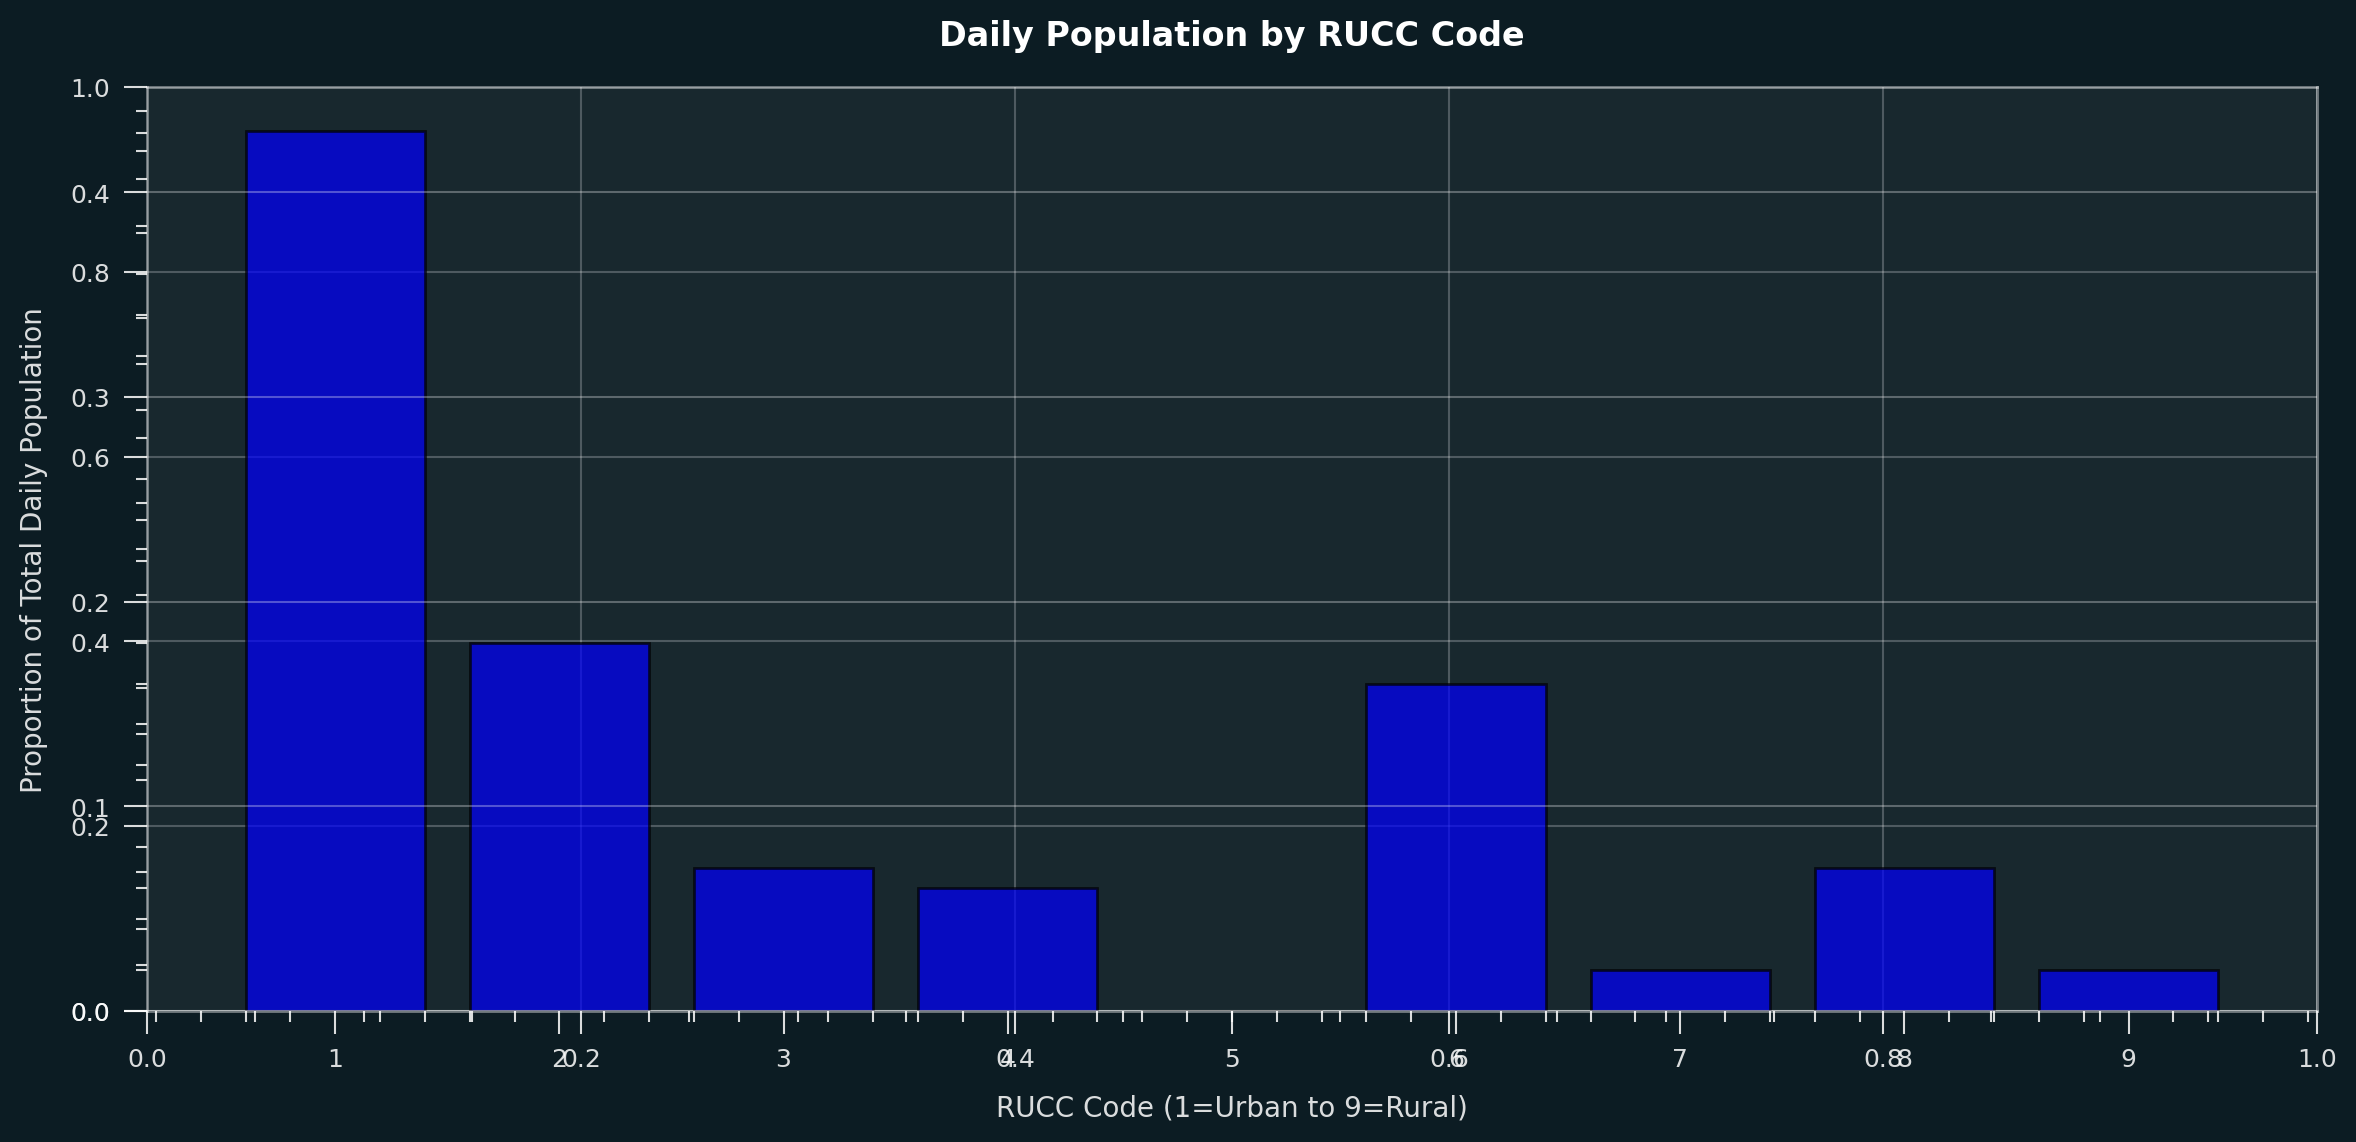

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    rucc_group["RUCC"],
    rucc_group["daily_pop"],
    edgecolor="black",
    alpha=0.7,
    color="blue",
    width=0.8,
)

ax.set_title("Daily Population by RUCC Code", fontsize=12, fontweight="bold")
ax.set_xlabel("RUCC Code (1=Urban to 9=Rural)", fontsize=10)
ax.set_ylabel("Proportion of Total Daily Population", fontsize=10)
ax.set_xticks(rucc_group["RUCC"])
ax.grid(False, axis="x")
ax.grid(True, axis="y", alpha=0.3)
fig.show()
